In [3]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib
import qRegNN as qrnn
import torch.nn as nn
import torch.nn.functional as F

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


# Load Data & Bkg

In [2]:
year = 2017
additional_vars = ['jet1_pt','jet1_eta','jet1_phi','jet2_pt','jet2_eta','jet2_phi']
data,unnorm_data,mass_data,names = hf.LAPS_train("DATA",year,num_batches=5,Mjj_cut=800,pt_cut=300,additional=additional_vars)
bkg,unnorm_bkg,mass_bkg,names = hf.LAPS_train("QCDBKG",year,num_batches=-1,Mjj_cut=800,pt_cut=300,additional=additional_vars)

# normalize to data mean/std
mean = data.mean(axis=0)
std = data.std(axis=0)

data = (data-mean)/std
bkg = (bkg-mean)/std

In [4]:
additional_vars = ['jet1_pt','jet1_eta','jet1_phi','jet2_pt','jet2_eta','jet2_phi']
year=2017
bkg,unnorm_bkg,mass_bkg,names = hf.LAPS_train("QCDBKG",year,num_batches=1,Mjj_cut=800,pt_cut=300,additional=additional_vars)
del bkg,unnorm_bkg,mass_bkg
data = np.load("QR_models/data.npy")
bkg = np.load("QR_models/bkg.npy")

# Create variable & data dicts

In [5]:
j1_varDict = {"pt":"jet1_pt",
              "eta":"jet1_eta",
              "phi":"jet1_phi",
              "m":r"$M_{j1}$",
              "tau21":r"Jet 1 $\tau_{21}$",
              "tau32":r"Jet 1 $\tau_{32}$",
              "tau43":r"Jet 1 $\tau_{43}$",
              "tauS":r"Jet 1 $\tau_s$",
              "pb":r"Jet 1 $P_b$",
              "npf":r"Jet 1 $n_{pf}$"}

j2_varDict = {"pt":"jet2_pt",
              "eta":"jet2_eta",
              "phi":"jet2_phi",
              "m":r"$M_{j2}$",
              "tau21":r"Jet 2 $\\tau_{21}$",
              "tau32":r"Jet 2 $\\tau_{32}$",
              "tau43":r"Jet 2 $\\tau_{43}$",
              "tauS":r"Jet 2 $\\tau_s$",
              "pb":r"Jet 2 $P_b$",
              "npf":r"Jet 2 $n_{pf}$"}

xlims = {
    "pt":[-2.5,10],
    "eta":[-2.5,2.5],
    "phi":[-2,2],
    "m":[-2,10],
    "tau21":[-3.5,3],
    "tau32":[-8,4],
    "tau43":[-10,6],
    "tauS":[-3,15],
    "pb":[-6,4],
    "npf":[-3,8]
}
#xlims = {v:[-3,3] for v in j1_varDict.keys()}

def getQuantiles(arr,num=30,lo=0.0001,hi=0.9999):
    from scipy.stats import percentileofscore
    x0 = np.quantile(arr,lo)
    x1 = np.quantile(arr,hi)
    spaces = np.linspace(x0,x1,num=num)
    qs = []
    for s in spaces:
        qs.append(np.mean(arr<=s))
    qs = np.array(qs)
    return qs[qs>0]

def makeQList(arr,edges,nums):
    qs = []
    for i in range(len(edges)-1):
        q = getQuantiles(arr,lo=edges[i],hi=edges[i+1],num=nums[i])
        if i == len(edges)-2:
            qs.append(q)
        else:
            qs.append(q[:-1])
    return np.concatenate(qs)

In [6]:
m_data = data[:,names.index(j1_varDict['m'])]
m_bkg = bkg[:,names.index(j1_varDict['m'])]

In [11]:
#j1_order = ["phi","tauS","tau21","tau32","tau43"]
#j1_order = ["phi","eta","pt","tauS"]
inds = {var:names.index(j1_varDict[var]) for var in j1_varDict.keys()}
qDict = {}

"""qDict["tau43"] = makeQList(data[:,inds["tau43"]],[0.0001,0.9999],[35])
qDict["tau32"] = makeQList(data[:,inds["tau32"]],[0.0001,0.9999],[35])
qDict["tau21"] = makeQList(data[:,inds["tau21"]],[0.0001,0.9999],[35])
qDict["tauS"] = makeQList(data[:,inds["tauS"]],[0.005,0.99999],[30])
qDict["m"] = makeQList(data[:,inds["m"]],[0.001,0.9,0.99999],[21,15])
qDict["pt"] = makeQList(data[:,inds["pt"]],[0.001,0.999],[30])
qDict["eta"] = makeQList(data[:,inds["eta"]],[0.001,0.999],[30])"""

j1_order = ["phi","eta","pt","m","tauS"]
widths = [[10,20,30],
          [10,20,30],
          [10,20,30],
          [10,20,30]]

qDict["eta"] = makeQList(data[:,inds["eta"]],[0.01,0.99],[30])
qDict["pt"] = makeQList(data[:,inds["pt"]],[0.001,0.999],[20])
qDict["m"] = makeQList(data[:,inds["m"]],[0.001,0.999],[20])
qDict["tauS"] = makeQList(data[:,inds["tauS"]],[0.005,0.99999],[20])

quantile_order = [np.array(qDict[var]) for var in j1_order[1:]]



# Mass Bin 1

Epoch 100, Loss: 0.22840064792528056
stopping early at epoch 113
Epoch 100, Loss: 0.10936312459883536
stopping early at epoch 140
Epoch 100, Loss: 0.10430815919984189
stopping early at epoch 153
Epoch 100, Loss: 0.004187459146277141
stopping early at epoch 148
0  Events with bad quantiles ( 0.0  %)
	 0  from bkg ( 0.0  %)
	 0  from data ( 0.0  %)
399  Underflow ( 0.04923117925331478  %)
447  Overflow ( 0.055153727133412794  %)
Epoch 100, Loss: 0.23207413706127564
stopping early at epoch 120
0  Events with bad quantiles ( 0.0  %)
	 0  from bkg ( 0.0  %)
	 0  from data ( 0.0  %)
8293  Underflow ( 1.0232435327011014  %)
7927  Overflow ( 0.9780841051153539  %)
stopping early at epoch 83
594  Events with bad quantiles ( 0.07329153001621297  %)
	 318  from bkg ( 0.03923687970564937  %)
	 352  from data ( 0.043432017787385466  %)
1  Underflow ( 0.0001233864141687087  %)
3235  Overflow ( 0.39915504983577266  %)
stopping early at epoch 84
3504  Events with bad quantiles ( 0.43234599524715533  %

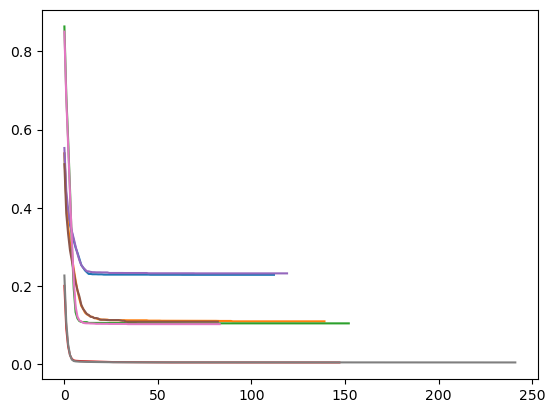

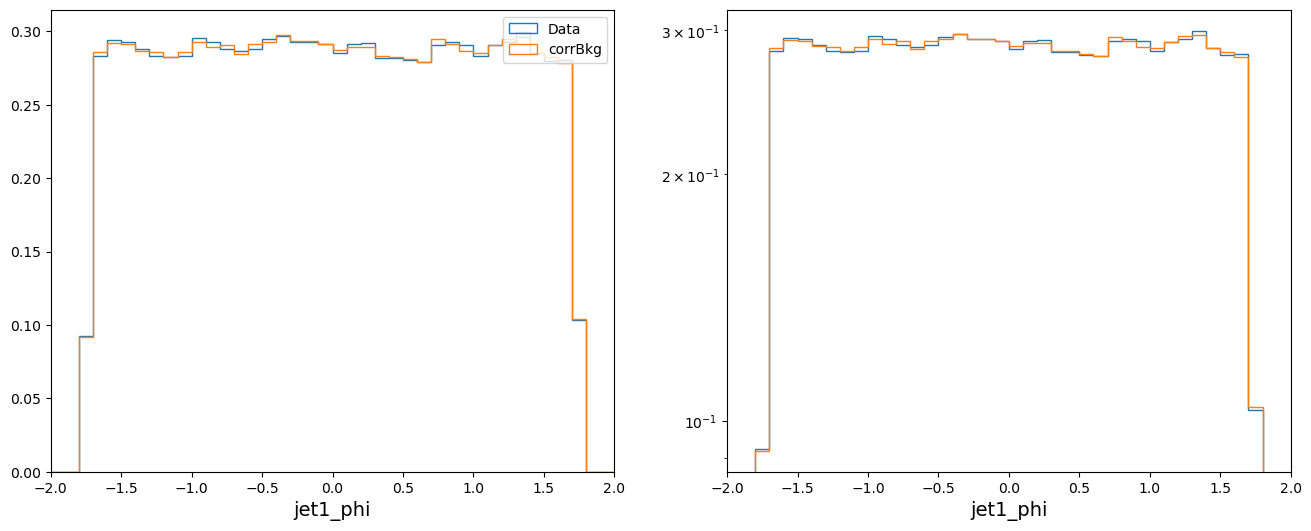

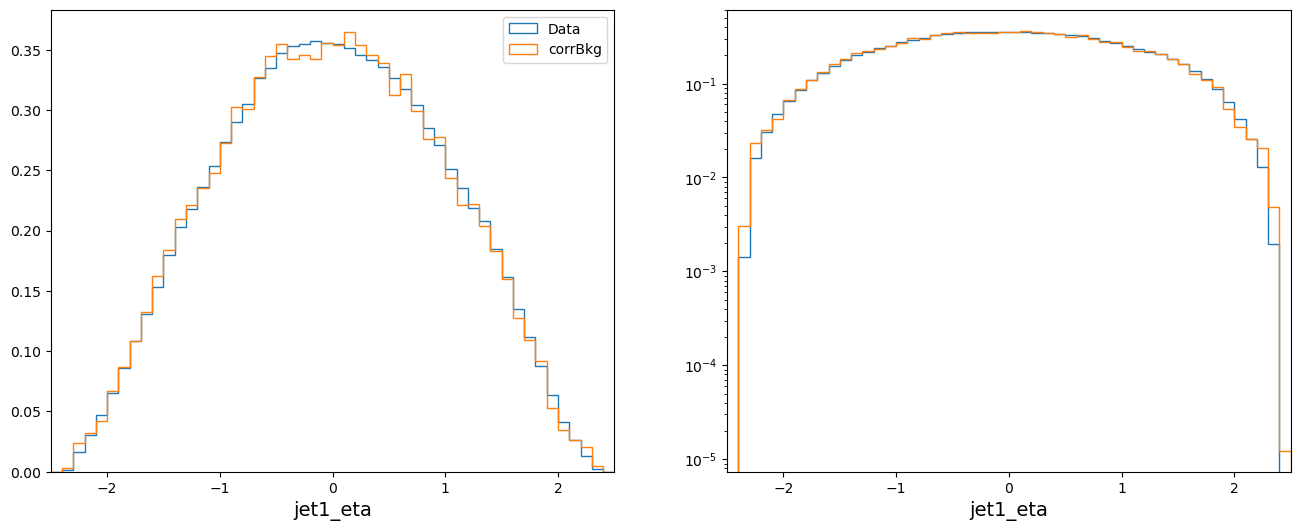

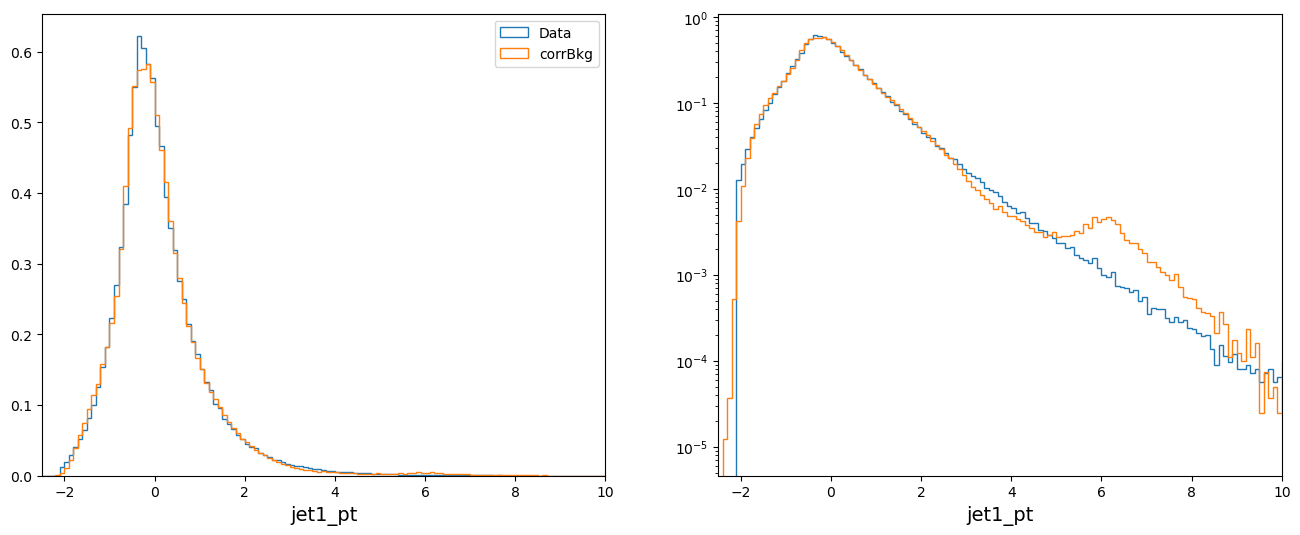

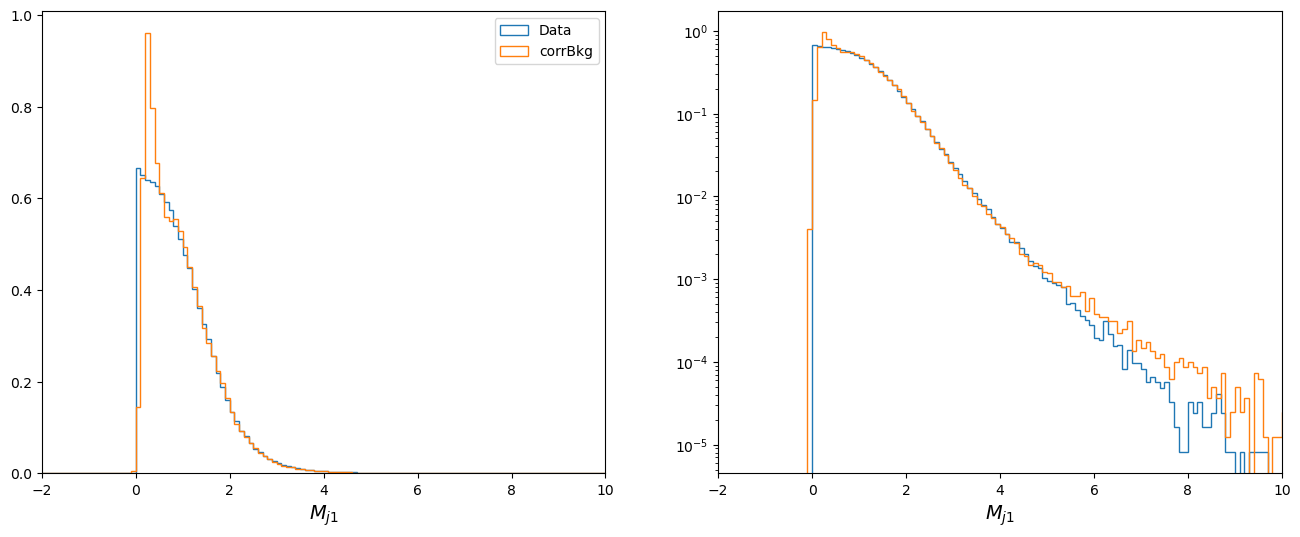

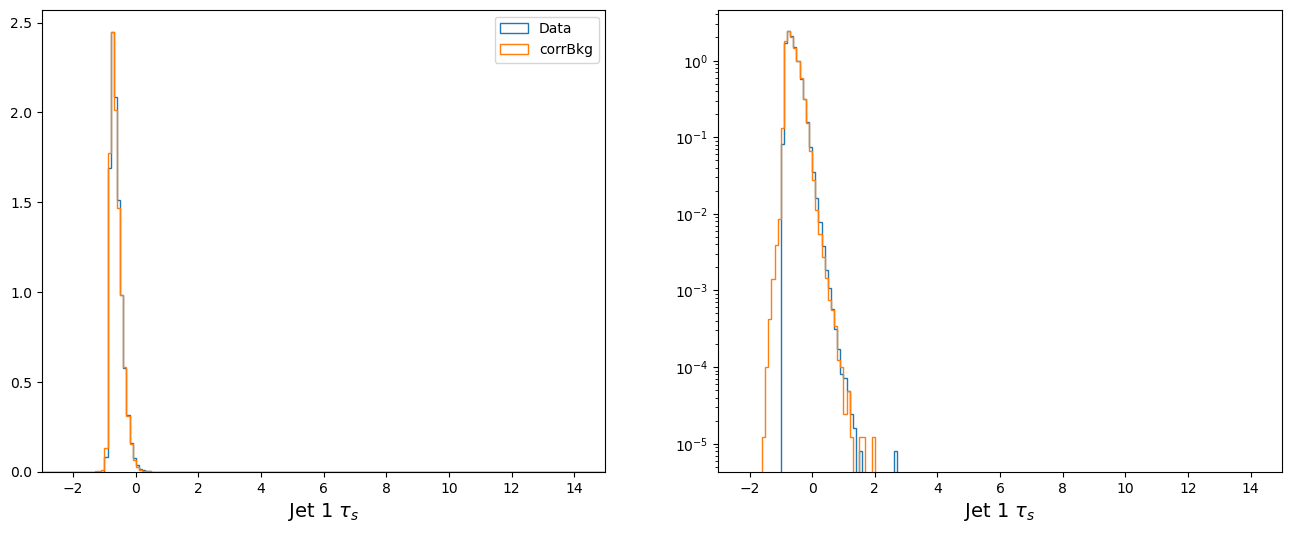

In [12]:
data2 = data[m_data>0]
bkg2 = bkg[m_bkg>0]
trainer = qrnn.chainedTrainer(data2.astype('float32'),bkg2.astype('float32'),names,j1_order,j1_varDict,widths,quantile_order,
                              act=nn.ReLU(),final_act=nn.Identity(),final_scale=1,
                              alpha=2.0,xlims=xlims)
trainer.trainData(nTrain=100000,bs=10000,batched=True,n_epoch=400,lr=5e-3)
trainer.trainBkg(nTrain=100000,bs=10000,batched=True,n_epoch=400,lr=5e-3,correctFirst=True)
trainer.plotCorrected()

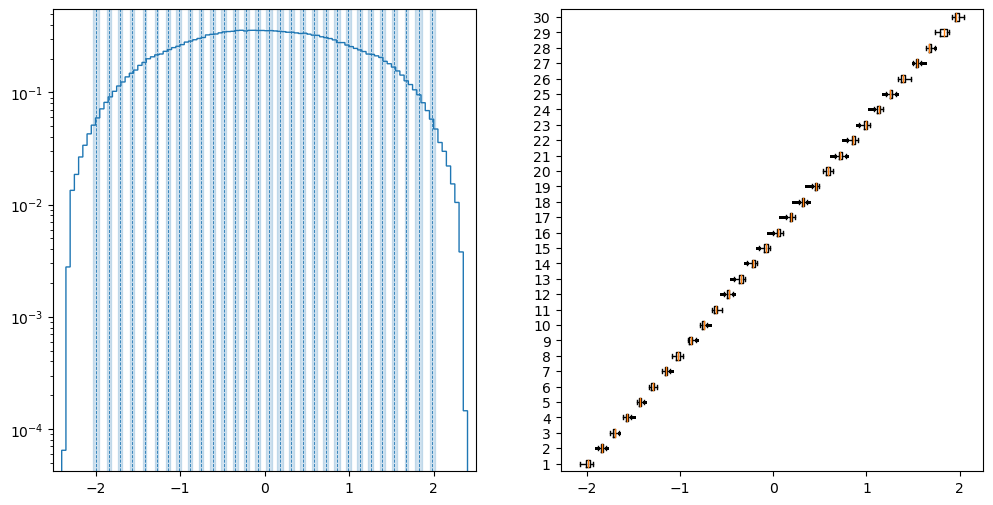

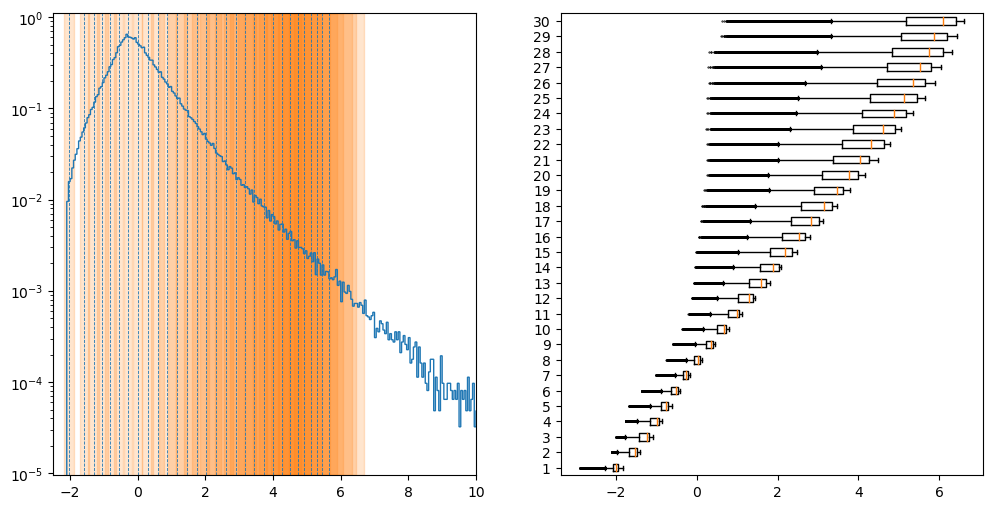

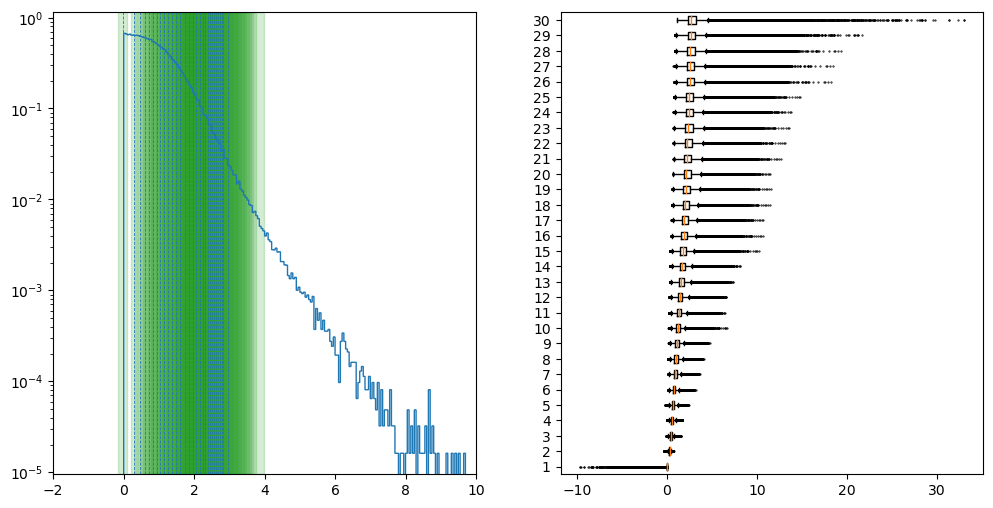

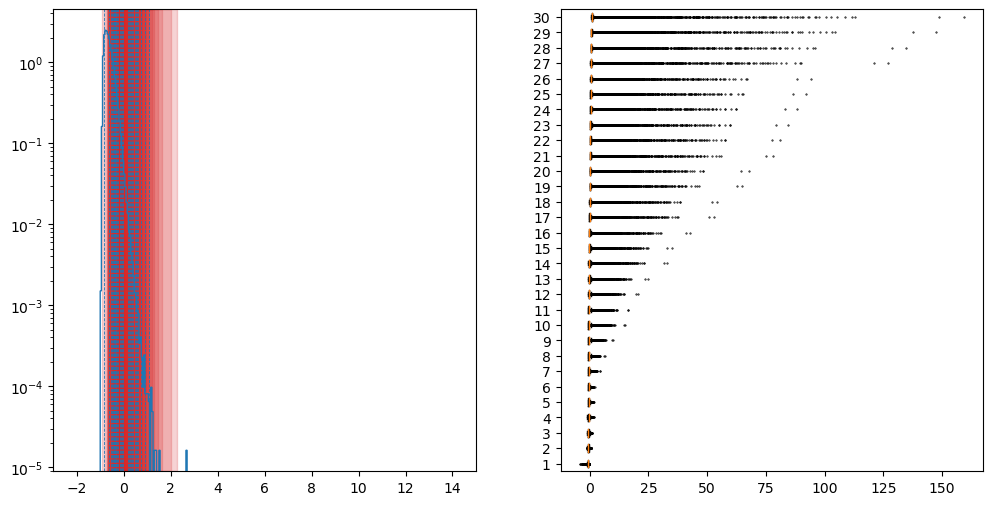

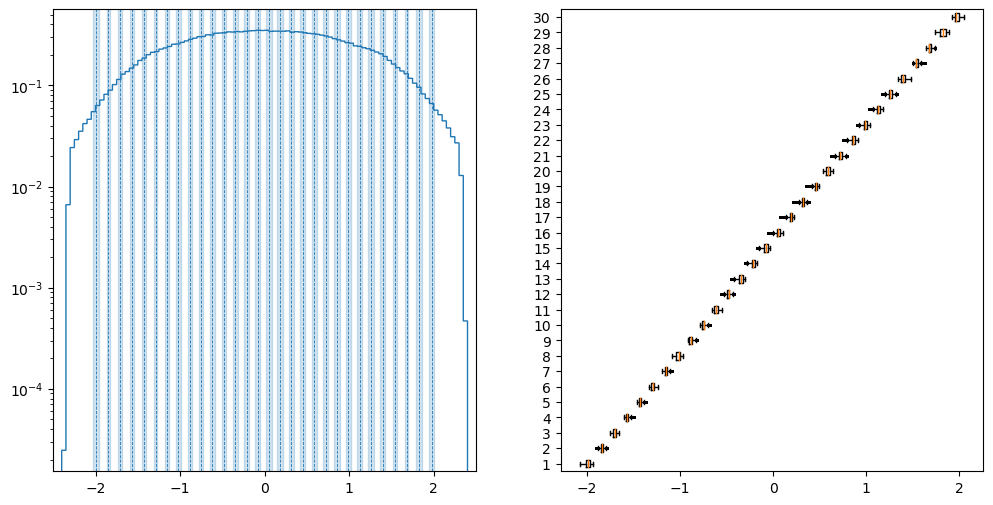

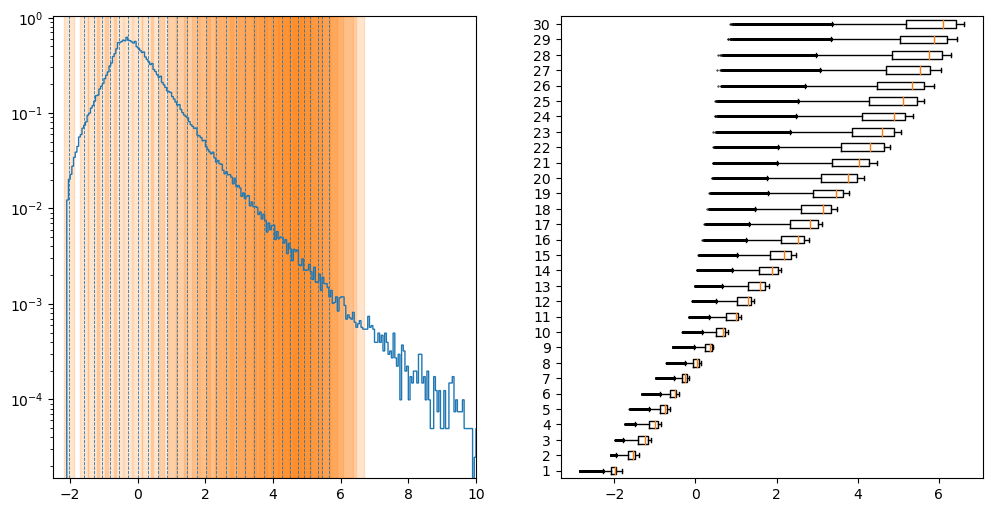

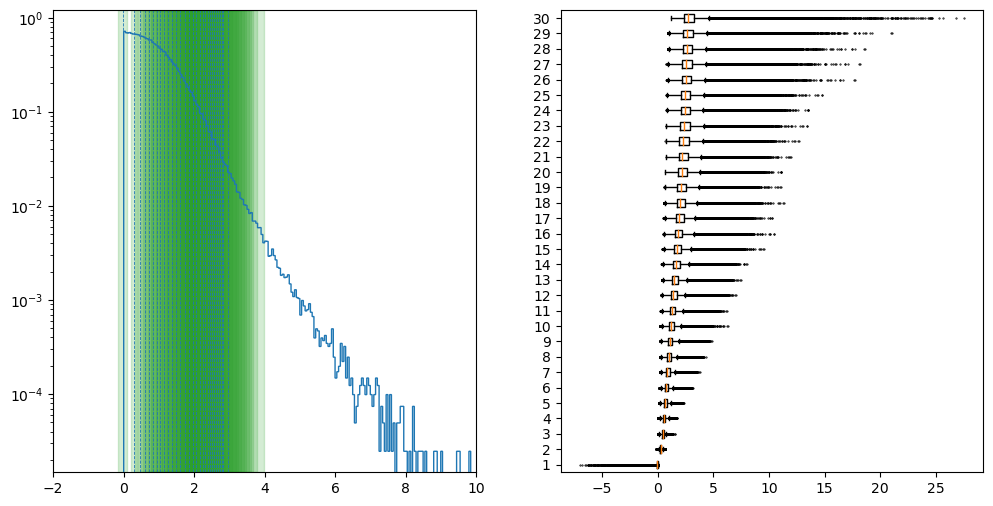

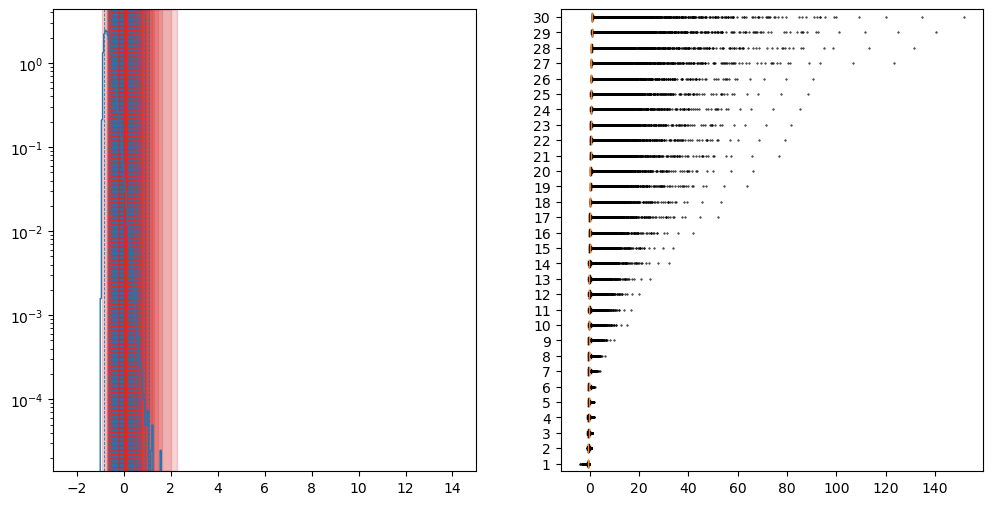

In [10]:
trainer.makeQuantilePlots(vert=False,log=True)
trainer.makeQuantilePlots(vert=False,log=True,data=False)

In [21]:
np.linspace(0.001,0.999,num=30)

array([0.001     , 0.03541379, 0.06982759, 0.10424138, 0.13865517,
       0.17306897, 0.20748276, 0.24189655, 0.27631034, 0.31072414,
       0.34513793, 0.37955172, 0.41396552, 0.44837931, 0.4827931 ,
       0.5172069 , 0.55162069, 0.58603448, 0.62044828, 0.65486207,
       0.68927586, 0.72368966, 0.75810345, 0.79251724, 0.82693103,
       0.86134483, 0.89575862, 0.93017241, 0.96458621, 0.999     ])

# Mass Bin 2

Epoch 100, Loss: 0.19248837902223248
Epoch 200, Loss: 0.19231745661127783
Epoch 300, Loss: 0.19226963695578927
Epoch 400, Loss: 0.19224117632905766
Epoch 500, Loss: 0.19222133710958283
Epoch 600, Loss: 0.19220669563578785
Epoch 700, Loss: 0.19219595867305825
Epoch 800, Loss: 0.19218837797361285
Epoch 900, Loss: 0.1921832023873431
Epoch 1000, Loss: 0.1921796908191989
Epoch 100, Loss: 0.19055566415201539
Epoch 200, Loss: 0.19022952059196382
Epoch 300, Loss: 0.189964679402575
Epoch 400, Loss: 0.18958017319129578
Epoch 500, Loss: 0.1893879620108712
Epoch 600, Loss: 0.18929078358122725
Epoch 700, Loss: 0.18923122281580096
Epoch 800, Loss: 0.1891870697869646
Epoch 900, Loss: 0.18915354383317937
Epoch 1000, Loss: 0.18912756572042305
Epoch 100, Loss: 0.22553172003767913
Epoch 200, Loss: 0.22508063001437867
Epoch 300, Loss: 0.22479335545037232
Epoch 400, Loss: 0.2245757059850163
Epoch 500, Loss: 0.2244699184260962
Epoch 600, Loss: 0.22439616984878247
Epoch 700, Loss: 0.22433241772641896
Epoch 8

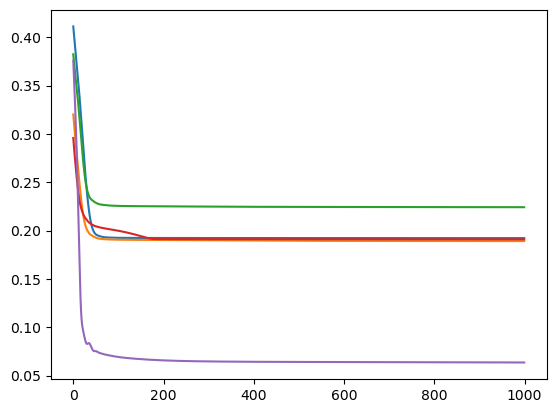

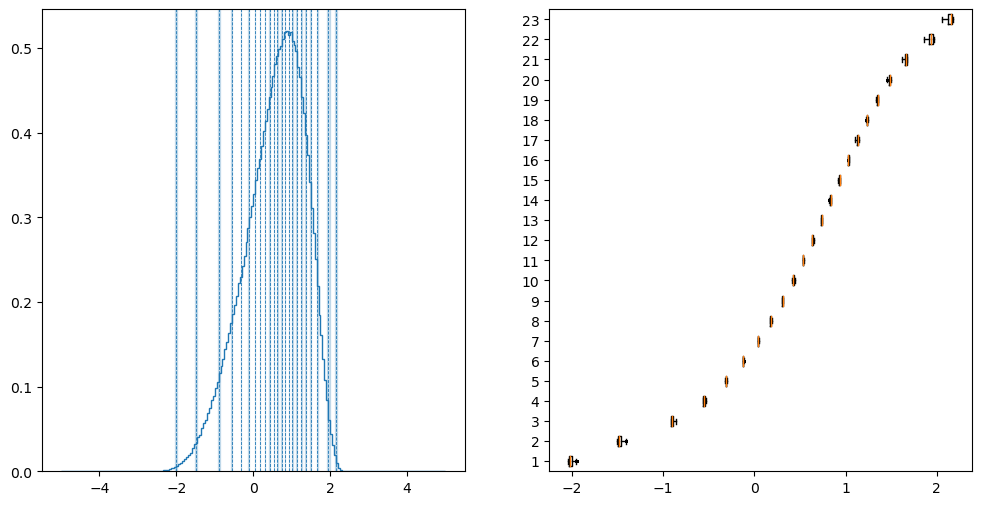

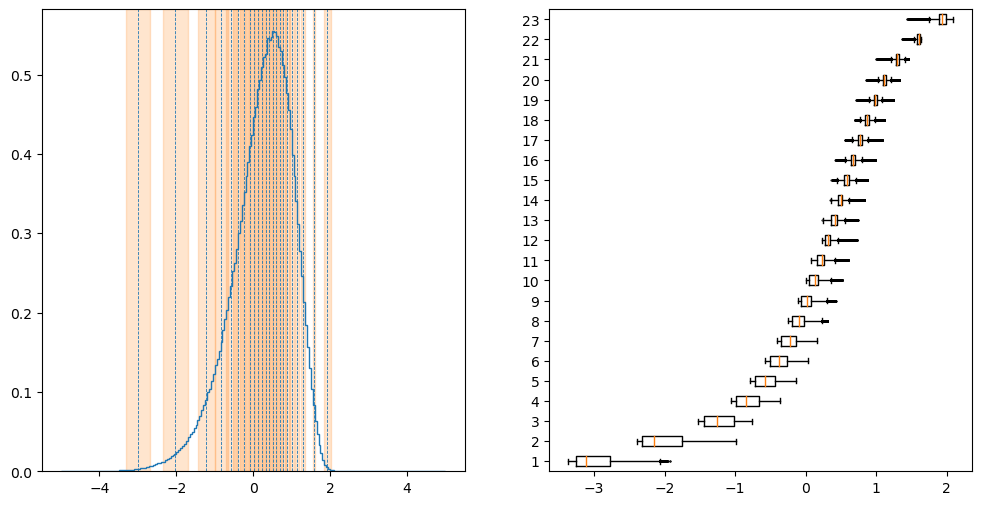

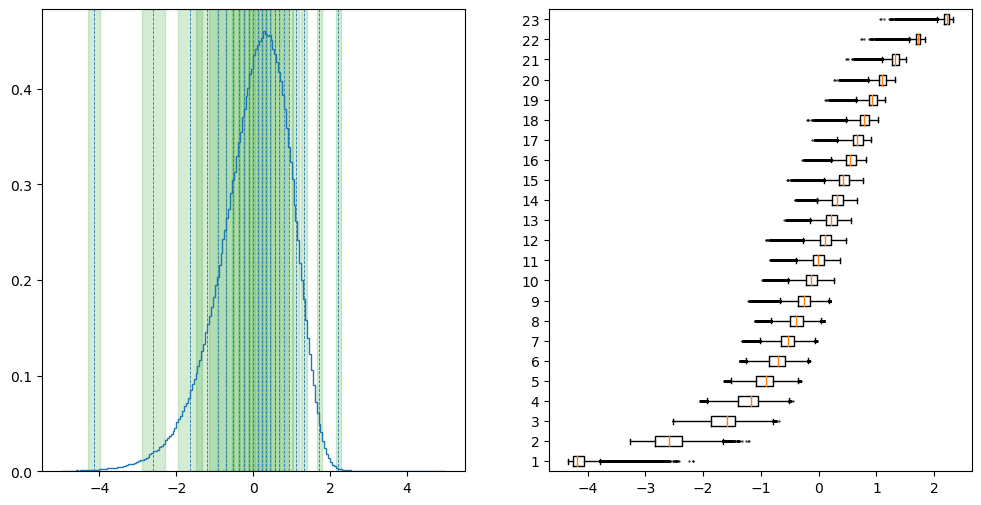

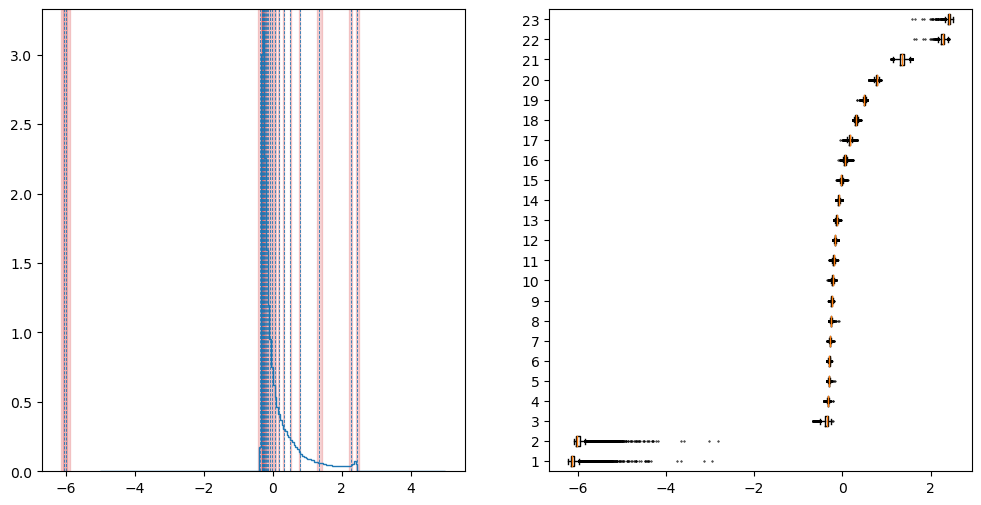

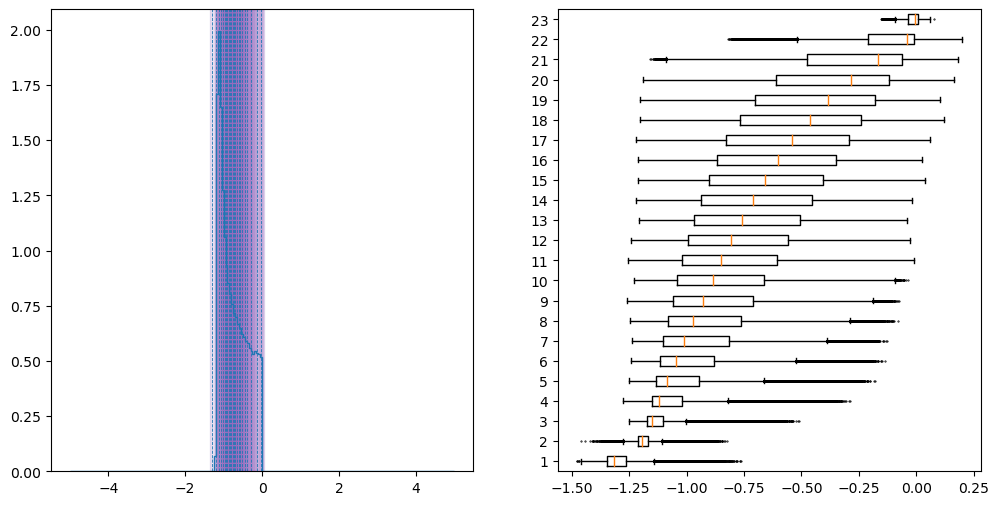

Epoch 100, Loss: 0.19916447016222716
Epoch 200, Loss: 0.19898280477182873
Epoch 300, Loss: 0.19894454083358948
Epoch 400, Loss: 0.1989239735677157
Epoch 500, Loss: 0.1989108036591847
Epoch 600, Loss: 0.19890176860565997
Epoch 700, Loss: 0.1988952596553278
Epoch 800, Loss: 0.19889040571079628
Epoch 900, Loss: 0.1988867505112942
Epoch 1000, Loss: 0.1988839641102038
There are 0 events with bad quantiles out of 1278141 (0.0000%)
0 (0.0000%) bkg only, 0 (0.0000%) data only, 0 (0.0000%) both
Epoch 100, Loss: 0.1847250659084676
Epoch 200, Loss: 0.18450070893719747
Epoch 300, Loss: 0.18446346178621842
Epoch 400, Loss: 0.1844474786503644
Epoch 500, Loss: 0.18443830358730587
Epoch 600, Loss: 0.18443198074142064
Epoch 700, Loss: 0.18442721544386353
Epoch 800, Loss: 0.18442350053194287
Epoch 900, Loss: 0.18442052908565618
Epoch 1000, Loss: 0.18441808779702462
There are 62 events with bad quantiles out of 1278141 (0.0049%)
0 (0.0000%) bkg only, 62 (0.0049%) data only, 0 (0.0000%) both
Epoch 100, Lo

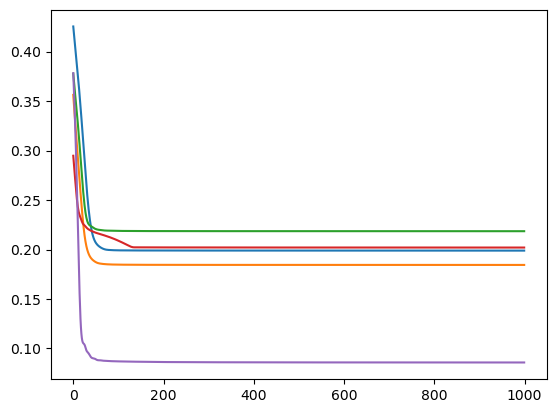

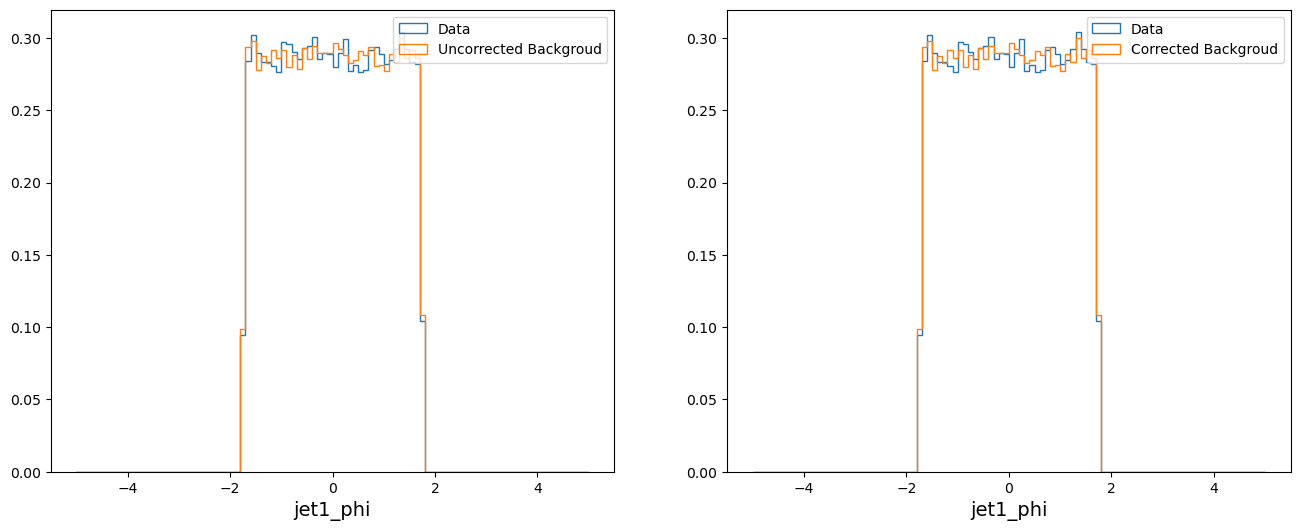

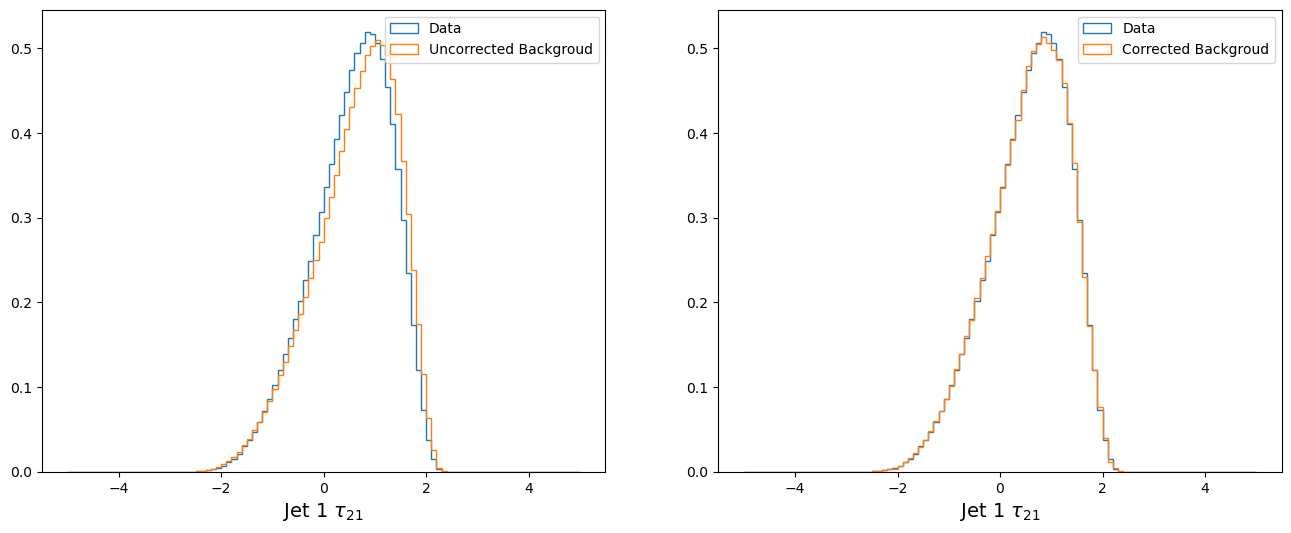

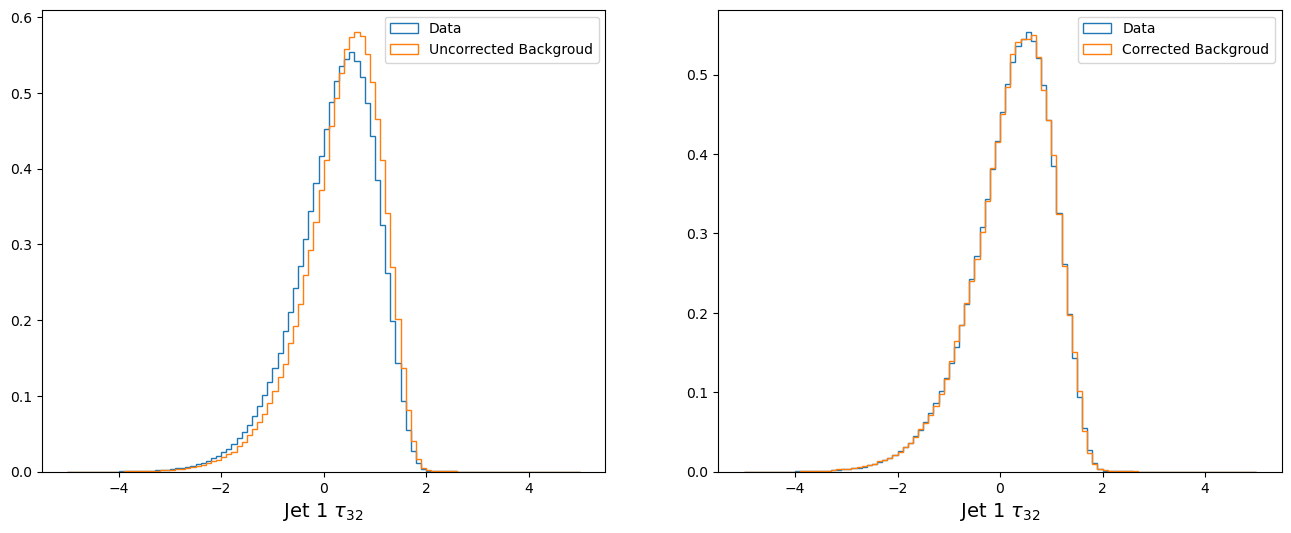

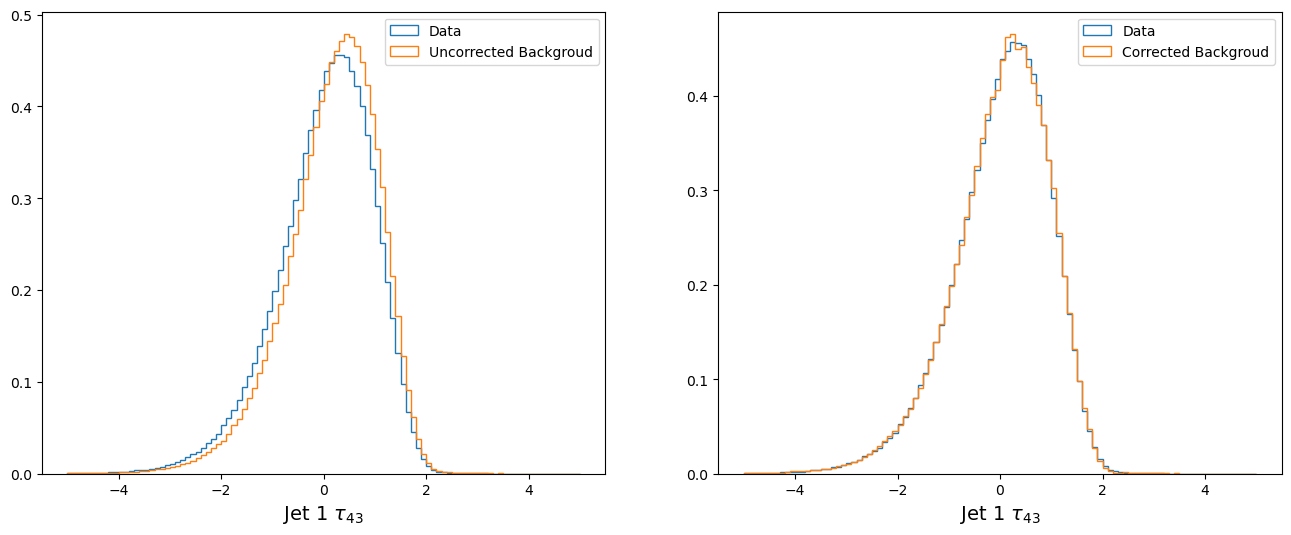

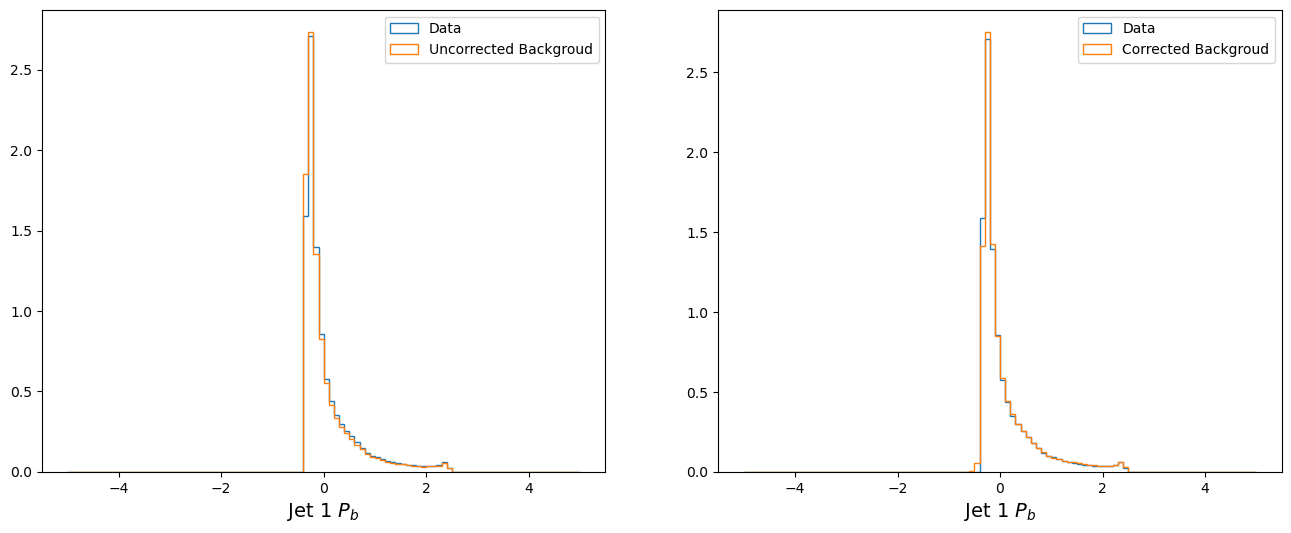

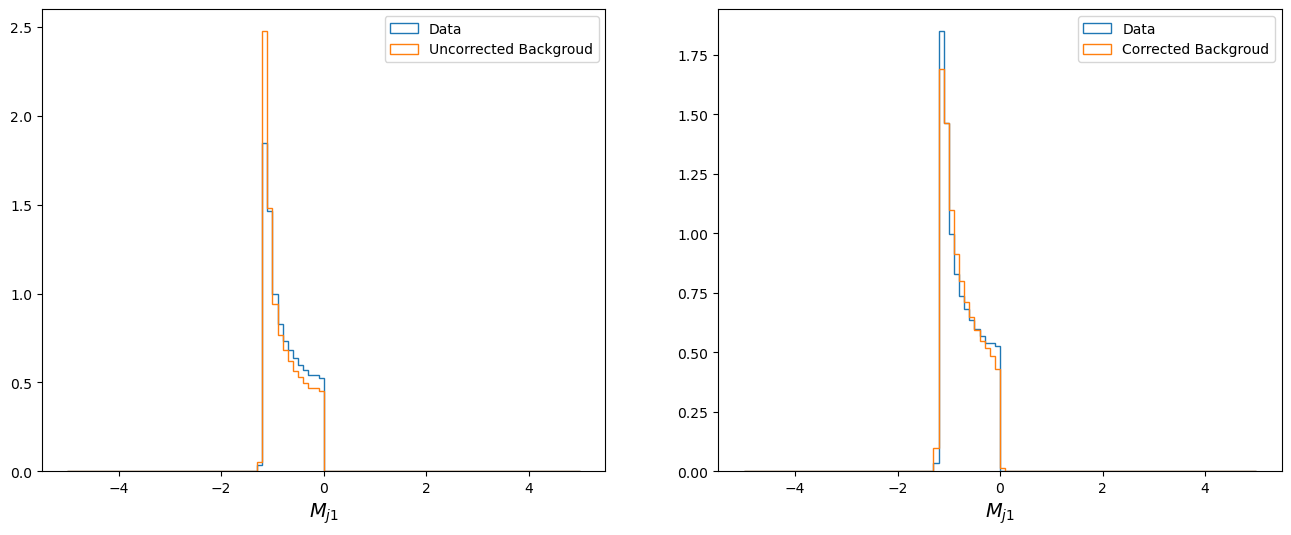

In [12]:
data2 = data[m_data<0]
bkg2 = bkg[m_bkg<0]
j1_order = ["phi","tau21","tau32","tau43","pb","m"]
widths = [(30,3),(40,3),(50,3),(60,3),(70,3)]
quantile_order = [q1,q1,q1,q1,q1,q2]
trainer = qrnn.chainedTrainer(data2,bkg2,names,j1_order,j1_varDict,widths,quantile_order)
trainer.trainData()
trainer.makeQuantilePlots()
trainer.trainBkg()
trainer.plotCorrected()

# Mass Bin 3

Epoch 100, Loss: 0.18153384009740822
Epoch 200, Loss: 0.1813700439088225
Epoch 300, Loss: 0.18131410945391968
Epoch 400, Loss: 0.18128083100614706
Epoch 500, Loss: 0.18125875345254208
Epoch 600, Loss: 0.18124333465779704
Epoch 700, Loss: 0.18123250144230932
Epoch 800, Loss: 0.18122497512231248
Epoch 900, Loss: 0.18121990543501612
Epoch 1000, Loss: 0.18121646982975265
Epoch 100, Loss: 0.1867432226619863
Epoch 200, Loss: 0.1865038553014979
Epoch 300, Loss: 0.18640658854224249
Epoch 400, Loss: 0.18628864725632716
Epoch 500, Loss: 0.18607233512999077
Epoch 600, Loss: 0.18585763796364918
Epoch 700, Loss: 0.18573095041187948
Epoch 800, Loss: 0.18566009928869828
Epoch 900, Loss: 0.18561302634577115
Epoch 1000, Loss: 0.1855763284615488
Epoch 100, Loss: 0.22663537109192786
Epoch 200, Loss: 0.22612183433800429
Epoch 300, Loss: 0.22585164987958573
Epoch 400, Loss: 0.2256180908318467
Epoch 500, Loss: 0.22546896499570337
Epoch 600, Loss: 0.22536727266589326
Epoch 700, Loss: 0.22528180570238465
Epoc

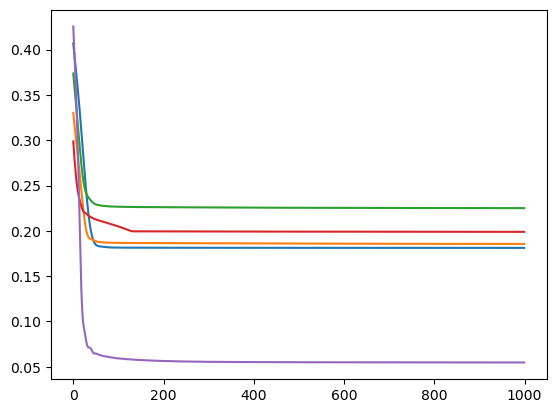

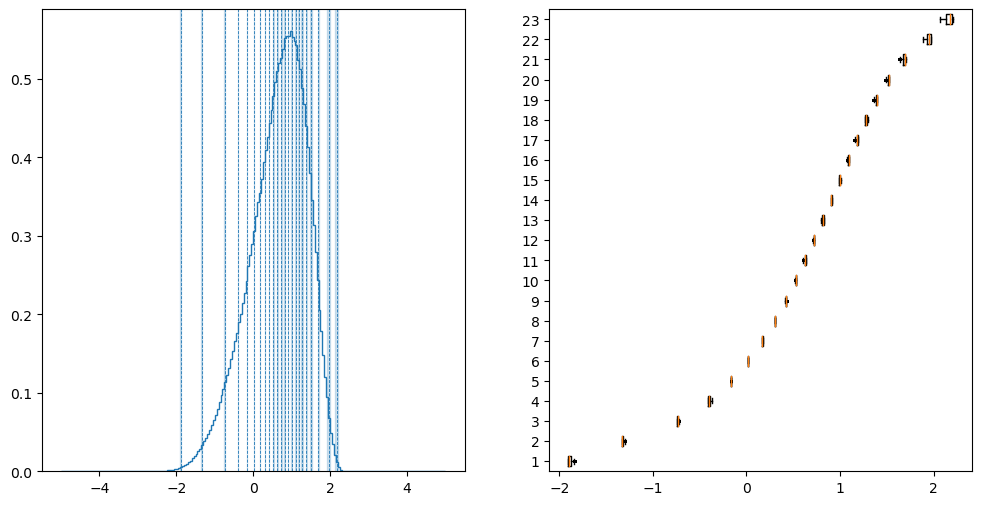

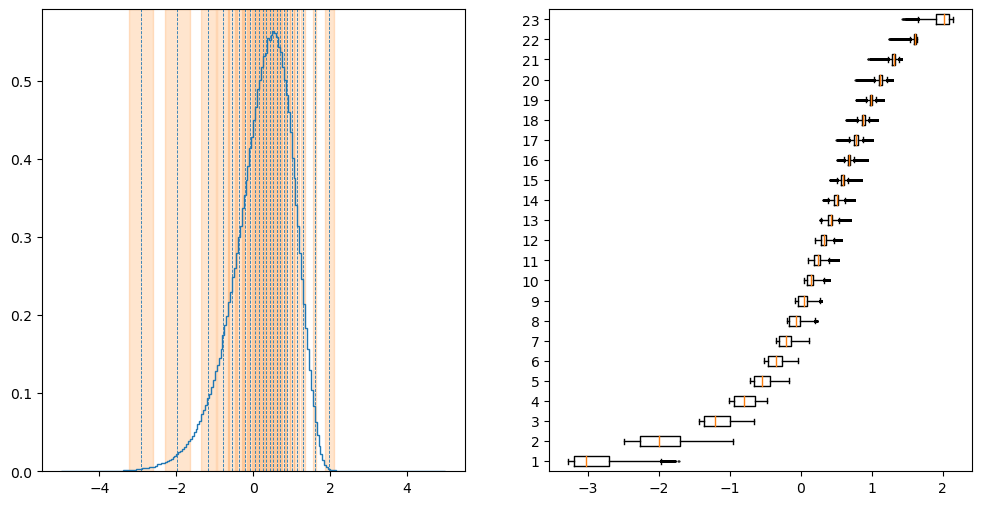

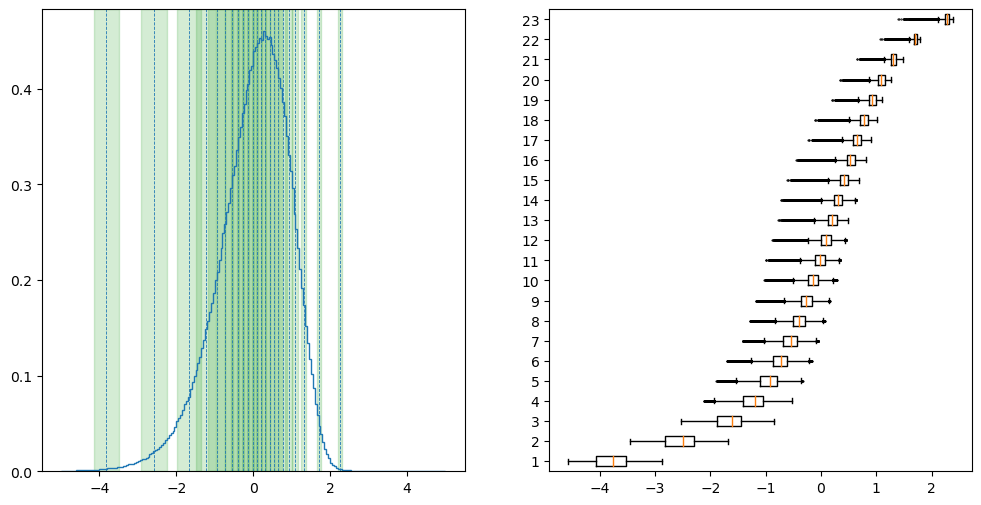

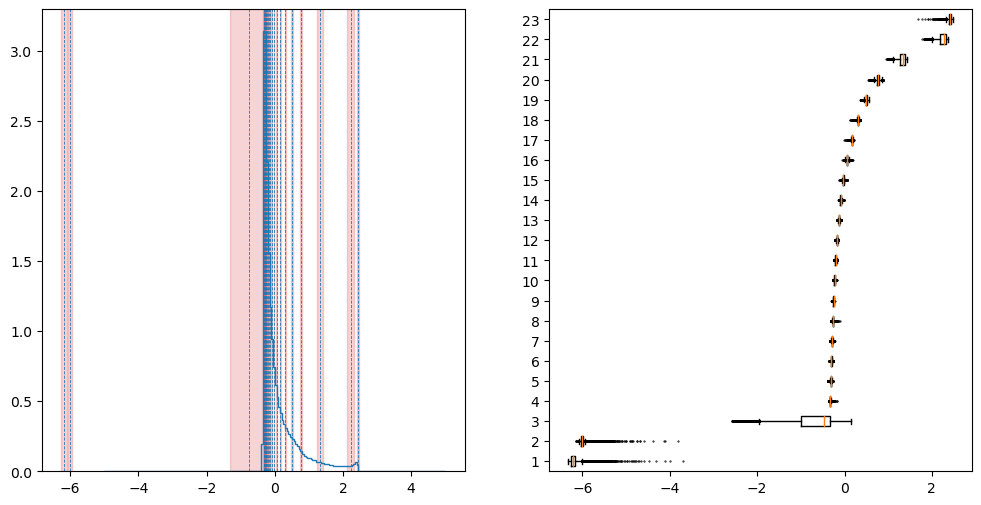

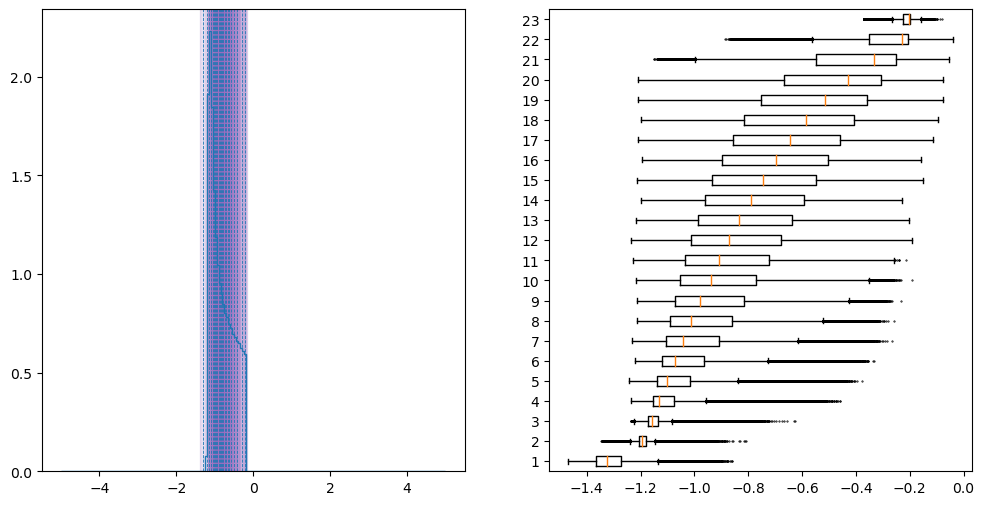

Epoch 100, Loss: 0.18670045774081184
Epoch 200, Loss: 0.1866012301707388
Epoch 300, Loss: 0.18656568313259692
Epoch 400, Loss: 0.18654132218729022
Epoch 500, Loss: 0.18652393260263708
Epoch 600, Loss: 0.18651156420790613
Epoch 700, Loss: 0.18650294946229268
Epoch 800, Loss: 0.18649732283924203
Epoch 900, Loss: 0.18649386057623651
Epoch 1000, Loss: 0.18649184257145968
There are 0 events with bad quantiles out of 1160422 (0.0000%)
0 (0.0000%) bkg only, 0 (0.0000%) data only, 0 (0.0000%) both
Epoch 100, Loss: 0.18049069481340485
Epoch 200, Loss: 0.180276115184255
Epoch 300, Loss: 0.1802215238215226
Epoch 400, Loss: 0.18019544606733734
Epoch 500, Loss: 0.18018019830486348
Epoch 600, Loss: 0.1801701358230074
Epoch 700, Loss: 0.18016289916892805
Epoch 800, Loss: 0.18015736706321375
Epoch 900, Loss: 0.18015314320667528
Epoch 1000, Loss: 0.1801499052904427
There are 103 events with bad quantiles out of 1160422 (0.0089%)
0 (0.0000%) bkg only, 103 (0.0089%) data only, 0 (0.0000%) both
Epoch 100,

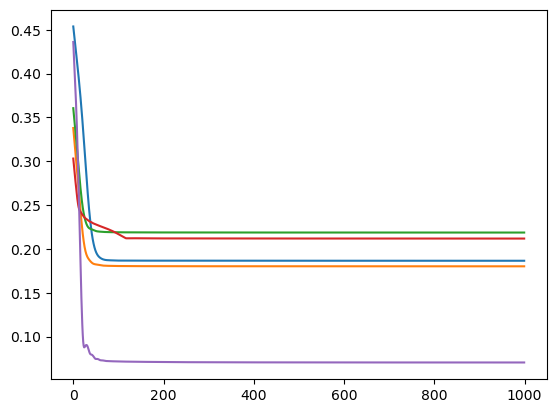

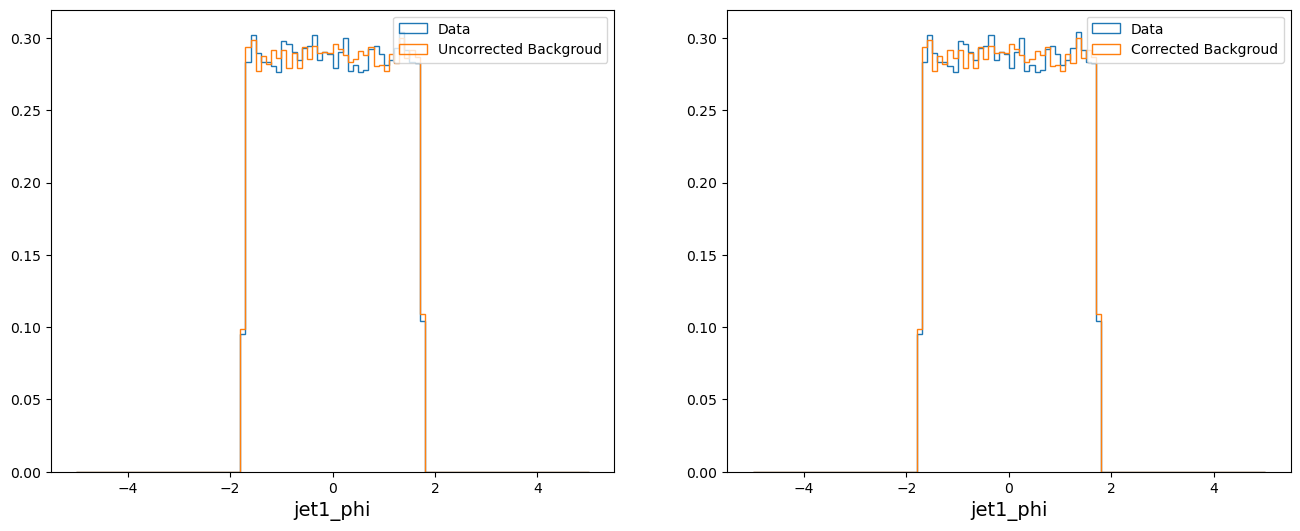

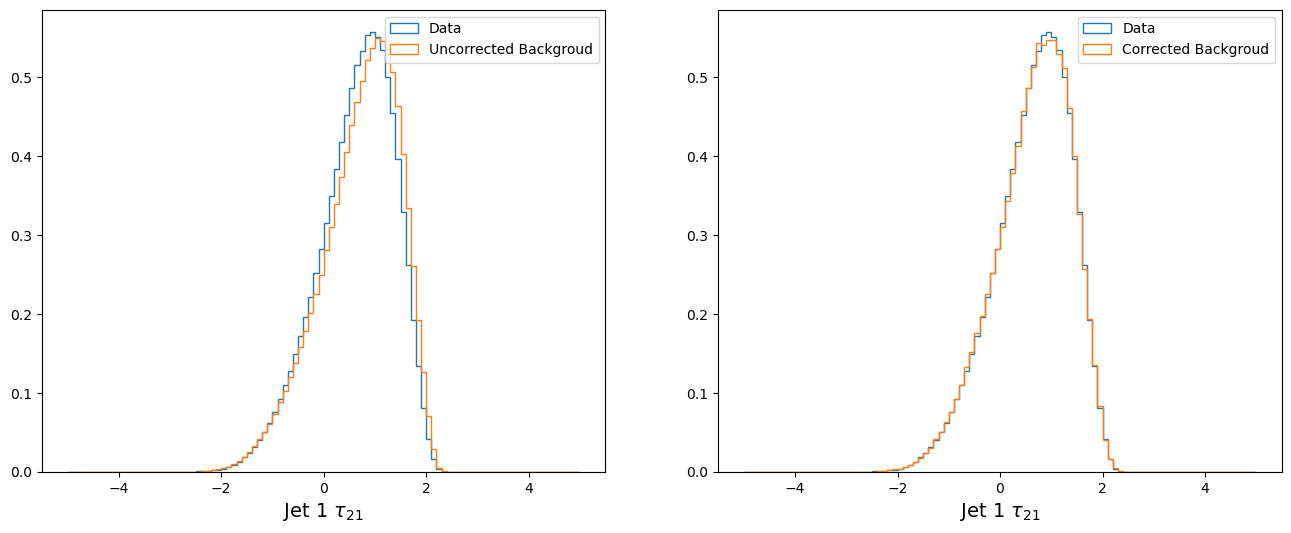

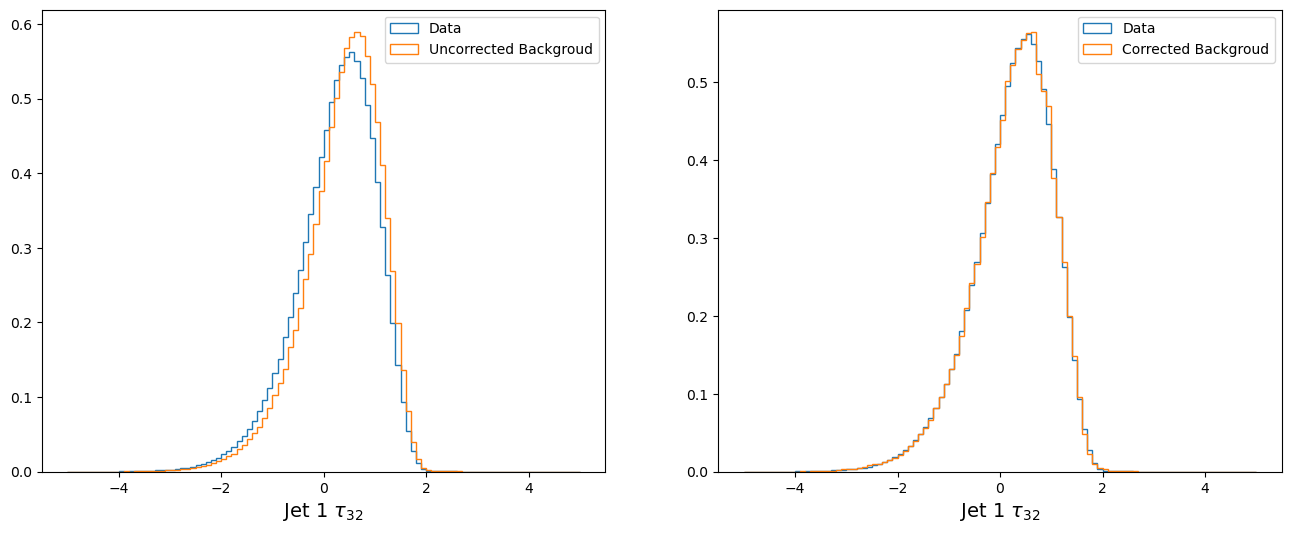

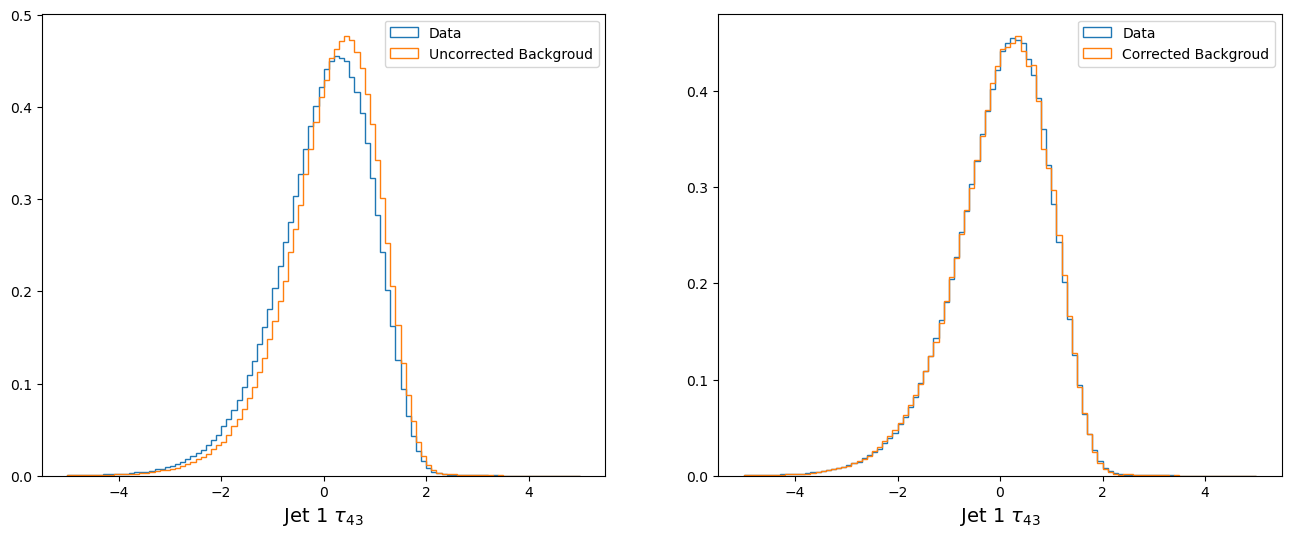

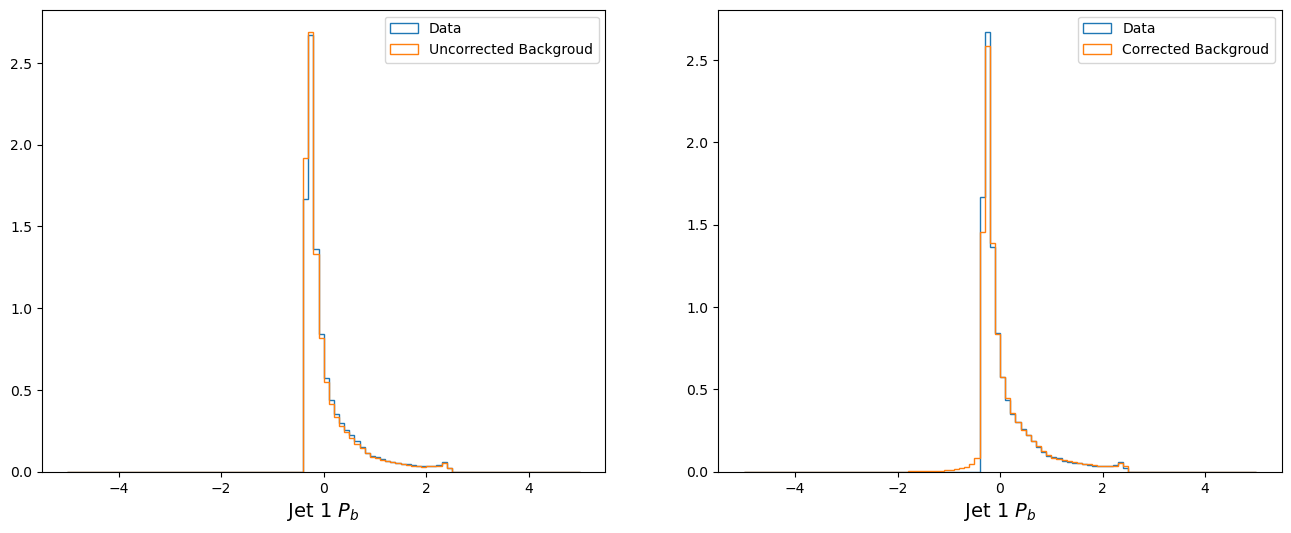

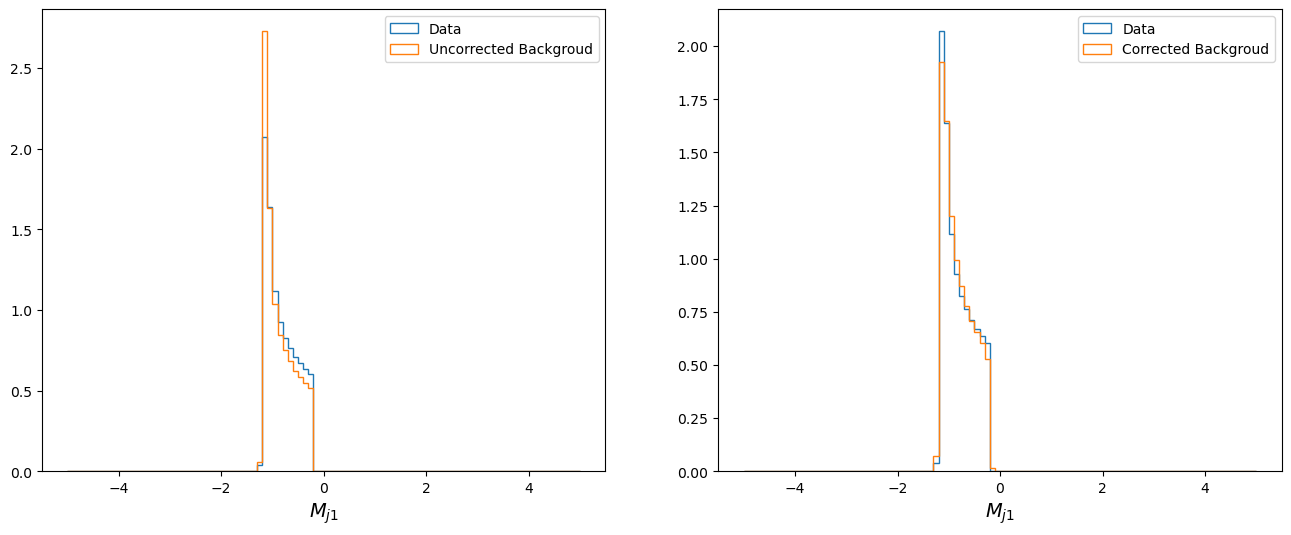

In [7]:
data2 = data[m_data<-0.2]
bkg2 = bkg[m_bkg<-0.2]
j1_order = ["phi","tau21","tau32","tau43","pb","m"]
widths = [(30,3),(40,3),(50,3),(60,3),(70,3)]
quantile_order = [q1,q1,q1,q1,q1,q2]
trainer = qrnn.chainedTrainer(data2,bkg2,names,j1_order,j1_varDict,widths,quantile_order)
trainer.trainData()
trainer.makeQuantilePlots()
trainer.trainBkg()
trainer.plotCorrected()

# Mass Bin 4

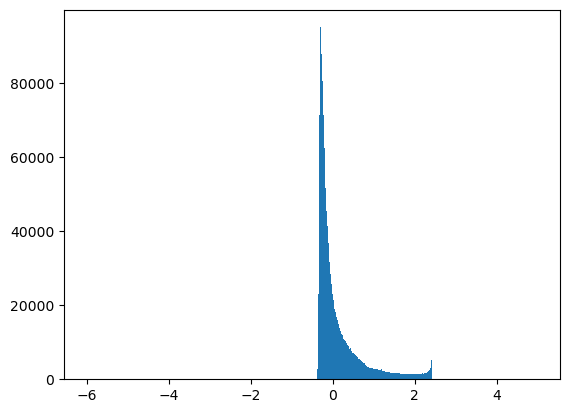

In [8]:
h = plt.hist(data[:,names.index(j1_varDict["pb"])],bins=np.linspace(-6,5,num=1000))